In [10]:
from itertools import combinations
from typing import Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import LocalOutlierFactor

from crucio import SMOTEENN

RANDOM_STATE = 42
TARGET_COL = "Outcome"

LEAKAGE_COLS = [
    "NS1",
    "IgG",
    "IgM",
    "Platelet_Count",
    "WBC_Count",
    "Body_Temperature",
    "Fever_Duration",
]

CATEGORICAL_COLS = ["Gender", "AreaType", "HouseType", "Joint_Pain"]
OUTLIER_PARAMS = {"n_neighbors": 20, "leaf_size": 30, "contamination": 0.05}
SELECTED_FEATURES = [
    "Headache",
    "Retro_Orbital_Pain",
    "Myalgia",
    "Rash",
    "Joint_Pain_None",
    "Joint_Pain_Severe",
]

poverty = pd.read_csv("area_poverty_table.csv")
df = pd.read_csv("data.csv")
df = df.rename(columns=lambda x: x.strip())
df = df.drop(columns=[col for col in LEAKAGE_COLS + ["District"] if col in df.columns])
df["Area_HCR"] = df["Area"].map(poverty.set_index("Area")["HCR_upper_2022"])


def add_area_binning(df: pd.DataFrame, poverty_df: pd.DataFrame, n_bins: int = 5) -> pd.DataFrame:
    out = df.copy()
    areas = (
        out[["Area", "Outcome"]]
        .dropna(subset=["Area"])
        .groupby("Area", as_index=False)
        .agg(n_patients=("Outcome", "size"))
        .merge(poverty_df[["Area", "HCR_upper_2022"]], on="Area", how="left")
        .sort_values(["HCR_upper_2022", "Area"], kind="mergesort")
        .reset_index(drop=True)
    )

    def find_balanced_cuts(sizes, n_bins=5):
        sizes = np.asarray(sizes, dtype=float)
        cumulative = np.concatenate([[0], sizes.cumsum()])
        target = sizes.sum() / n_bins
        best_score, best_bounds = None, None
        for cuts in combinations(range(1, len(sizes)), n_bins - 1):
            bounds = (0,) + cuts + (len(sizes),)
            counts = np.diff(cumulative[list(bounds)])
            deviations = np.abs(counts - target)
            score = (deviations.max(), (deviations ** 2).sum())
            if best_score is None or score < best_score:
                best_score, best_bounds = score, bounds
        return list(best_bounds), best_score

    bounds, _ = find_balanced_cuts(areas["n_patients"].values, n_bins=n_bins)
    inner_edges = [
        round((areas.loc[b - 1, "HCR_upper_2022"] + areas.loc[b, "HCR_upper_2022"]) / 2, 3)
        for b in bounds[1:-1]
    ]
    bin_edges = [-np.inf] + inner_edges + [np.inf]
    bin_labels = [f"Q{i}" for i in range(1, n_bins + 1)]
    area_to_hcr = poverty_df.set_index("Area")["HCR_upper_2022"]
    out["Area_HCR"] = out["Area"].map(area_to_hcr)
    out["Area_bin"] = pd.cut(out["Area_HCR"], bins=bin_edges, labels=bin_labels, ordered=True)
    out["Area_bin_code"] = out["Area_bin"].cat.codes
    out = out.drop(columns=["Area_bin", "Area_HCR"])
    return out


def add_age_binning(df: pd.DataFrame, balance_tolerance: float = 0.10) -> pd.DataFrame:
    out = df.copy()
    age_counts = (
        out.groupby("Age")
        .agg(n_patients=("Outcome", "size"), positive_rate=("Outcome", "mean"))
        .sort_index()
    )

    def enumerate_splits(n_groups, n_bins):
        return np.array(
            [(0,) + cuts + (n_groups,) for cuts in combinations(range(1, n_groups), n_bins - 1)],
            dtype=np.int32,
        )

    def score_splits(splits, group_sizes, group_positives):
        group_sizes = np.asarray(group_sizes, dtype=float)
        group_positives = np.asarray(group_positives, dtype=float)
        cum_n = np.concatenate([[0], group_sizes.cumsum()])
        cum_p = np.concatenate([[0], group_positives.cumsum()])
        n = np.diff(cum_n[splits], axis=1)
        p = np.diff(cum_p[splits], axis=1)
        total_n, total_p = group_sizes.sum(), group_positives.sum()
        target = total_n / (splits.shape[1] - 1)
        expected_pos = n * total_p / total_n
        expected_neg = n * (total_n - total_p) / total_n
        with np.errstate(divide="ignore", invalid="ignore"):
            chi2 = np.nan_to_num(
                (p - expected_pos) ** 2 / expected_pos + ((n - p) - expected_neg) ** 2 / expected_neg
            ).sum(axis=1)
        rates = np.divide(p, n, out=np.full_like(p, np.nan), where=n > 0)
        return {
            "n": n,
            "rates": rates,
            "balance_deviation": np.abs(n - target).max(axis=1),
            "rate_spread": np.nanmax(rates, axis=1) - np.nanmin(rates, axis=1),
            "chi2": chi2,
        }

    age_values = age_counts.index.to_numpy()
    age_sizes = age_counts["n_patients"].to_numpy()
    age_positives = out.groupby("Age")["Outcome"].sum().sort_index().to_numpy()
    splits = enumerate_splits(len(age_values), 5)
    scores = score_splits(splits, age_sizes, age_positives)
    tol = balance_tolerance * len(out) / 5
    allowed = np.where(scores["balance_deviation"] <= tol)[0]
    if len(allowed) == 0:
        raise ValueError("No age split satisfies the balance tolerance.")
    chosen = allowed[scores["chi2"][allowed].argmax()]
    age_bounds = splits[chosen]
    age_edges = [-np.inf] + [(age_values[b - 1] + age_values[b]) / 2 for b in age_bounds[1:-1]] + [np.inf]
    age_labels = [f"{age_values[age_bounds[i]]}-{age_values[age_bounds[i + 1] - 1]}" for i in range(5)]
    out["Age_bin"] = pd.cut(out["Age"], bins=age_edges, labels=age_labels, ordered=True)
    out = pd.get_dummies(out, columns=["Age_bin"], drop_first=True, dtype=int)
    return out


def prepare_features(df: pd.DataFrame, reference: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["Joint_Pain"] = out["Joint_Pain"].fillna("None")
    for col in out.select_dtypes(include="number"):
        out[col] = out[col].fillna(reference[col].median())
    for col in CATEGORICAL_COLS:
        out[col] = out[col].fillna(reference[col].mode()[0])
    return pd.get_dummies(out, columns=CATEGORICAL_COLS, drop_first=True, dtype=int)


def split_train_val_test(df: pd.DataFrame, random_state: int = RANDOM_STATE) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    df_dev, df_test = train_test_split(df, test_size=0.1, random_state=random_state)
    df_train, df_val = train_test_split(df_dev, test_size=1 / 9, random_state=random_state)
    return df_train, df_val, df_test


def apply_outlier_filter(X_train: pd.DataFrame, y_train: pd.Series, random_state: int = RANDOM_STATE) -> Tuple[pd.DataFrame, pd.Series]:
    detector = LocalOutlierFactor(**OUTLIER_PARAMS)
    labels = detector.fit_predict(X_train)
    mask = pd.Series(labels == 1, index=X_train.index)
    X_filtered = X_train.loc[mask].copy()
    y_filtered = y_train.loc[mask].copy()
    return X_filtered, y_filtered


def apply_binning(df: pd.DataFrame) -> pd.DataFrame:
    df = add_area_binning(df, poverty)
    return add_age_binning(df)


df_train_raw, df_val_raw, df_test_raw = split_train_val_test(df, RANDOM_STATE)
df_train = apply_binning(prepare_features(df_train_raw, reference=df_train_raw))
df_val = apply_binning(prepare_features(df_val_raw, reference=df_train_raw))
df_test = apply_binning(prepare_features(df_test_raw, reference=df_train_raw))

X_train_raw = df_train.drop(columns=[TARGET_COL]).copy()
y_train_raw = df_train[TARGET_COL].copy()
X_val = df_val.drop(columns=[TARGET_COL]).copy()
y_val = df_val[TARGET_COL].copy()
X_test = df_test.drop(columns=[TARGET_COL]).copy()
y_test = df_test[TARGET_COL].copy()

X_train_f, y_train_f = apply_outlier_filter(X_train_raw[SELECTED_FEATURES], y_train_raw, random_state=RANDOM_STATE)
X_train_sel = X_train_f.reindex(columns=SELECTED_FEATURES, fill_value=0).reset_index(drop=True)
X_val_sel = X_val.reindex(columns=SELECTED_FEATURES, fill_value=0).reset_index(drop=True)
X_test_sel = X_test.reindex(columns=SELECTED_FEATURES, fill_value=0).reset_index(drop=True)

proc_df = X_train_sel.copy()
proc_df[TARGET_COL] = y_train_f.reset_index(drop=True).astype(int)
balanced_df = SMOTEENN().balance(proc_df, TARGET_COL)
X_train_balanced = balanced_df.drop(columns=[TARGET_COL]).reset_index(drop=True)
y_train_balanced = balanced_df[TARGET_COL].astype(int).reset_index(drop=True)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_balanced)
X_val_scaled = scaler.transform(X_val_sel)
X_test_scaled = scaler.transform(X_test_sel)


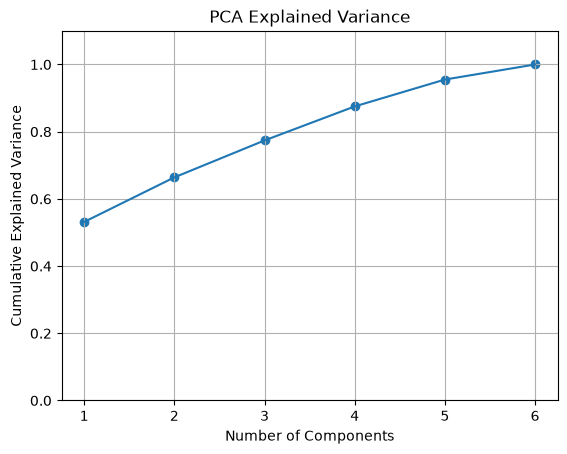

In [6]:
pca = PCA(n_components=X_train_scaled.shape[1], random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

cumulative_variances = np.cumsum(pca.explained_variance_ratio_)

plt.plot(range(1, len(cumulative_variances) + 1), cumulative_variances)
plt.scatter(range(1, len(cumulative_variances) + 1), cumulative_variances)
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.ylim(0, 1.1)
plt.title('PCA Explained Variance')
plt.grid()

In [7]:
cumulative_variances

array([0.53147257, 0.66406905, 0.77396417, 0.87522355, 0.95518285,
       1.        ])

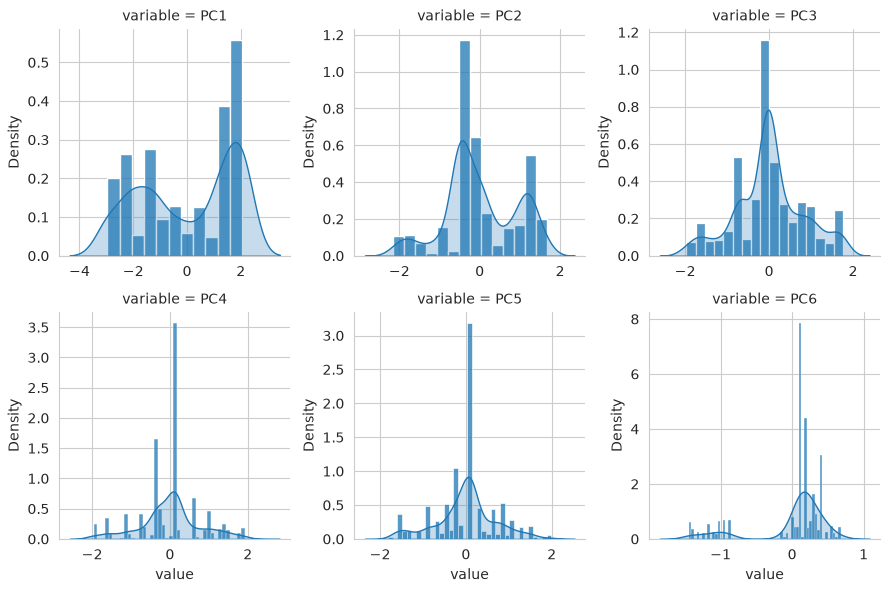

In [11]:
pca_df = pd.DataFrame(X_train_pca, columns=[f'PC{i}' for i in range(1, X_train_pca.shape[1] + 1)])
kde_cols = list(pca_df.columns)

with sns.axes_style('whitegrid'):
  nd = pd.melt(pca_df, value_vars=kde_cols)
  n1 = sns.FacetGrid(nd, col='variable', col_wrap=3, sharex=False, sharey=False)

  n1.map(
      sns.histplot,
      'value',
      stat='density',
  )

  n1.map(
      sns.kdeplot,
      'value',
      fill=True
  )